# ERP (Fed Model) Valuation Signal — 역사적 vs 최근 10년 baseline 실험

## 목적
현재 패시브 앱의 시장 밸류 탭은 **최근 15년** ERP 분포 기반 z-score 라벨링을 사용.
이 노트북에서는 **두 가지 대안 baseline** 을 비교한다:

1. **역사적 baseline (1871~today)**: Shiller 전체 데이터. mean/std 가 모두 큼 (옛날 변동성 큼).
2. **최근 10년 baseline (2016~today)**: 저금리·고PE 시대만. mean 작고 std 작음.

## 가설
- **H1**: 역사적 baseline → 오늘 ERP 의 z-score 가 **덜 음수** (덜 고평가로 보임). std 가 크기 때문.
- **H2**: 10년 baseline → mean 작고 std 작음 → 같은 ERP 변동에도 z-score 가 더 sensitive.
- **H3**: SPY 10% 하락 구간 (2026-03) 에서 10년 baseline 쪽 라벨 변동이 더 큼.

## 검증 방법
1. Shiller (1871~) + yfinance (2023~) 합성 → 두 기간 baseline mean/std 산출
2. 동일한 60일 ERP 시계열에 두 baseline 적용 → z-score 시계열
3. 라벨 분포 + 시각화 비교

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, date

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('ready')

ready


## 1. Shiller 데이터 다운로드 (1871-01 ~ 2023-XX)

Shiller's `ie_data.xls` 는 monthly P (S&P 500), E (TTM earnings), GS10 (10Y Treasury) 를 1871-01 부터 제공.
ERP_t = E_t/P_t - GS10_t/100

In [2]:
url = 'http://www.econ.yale.edu/~shiller/data/ie_data.xls'
sh = pd.read_excel(url, sheet_name='Data', skiprows=7)
sh = sh[['Date', 'P', 'E', 'Rate GS10']].dropna()
sh = sh[sh['Date'].apply(lambda x: isinstance(x, (int, float)))].copy()
sh['year'] = sh['Date'].apply(int)
sh['mo'] = sh['Date'].apply(lambda x: round((x - int(x)) * 100))
sh['ym'] = sh.apply(lambda r: f'{r.year:04d}-{r.mo:02d}', axis=1)
sh['ey'] = sh['E'] / sh['P']
sh['tnx'] = sh['Rate GS10'] / 100
sh['erp'] = sh['ey'] - sh['tnx']

print(f'Shiller 행 수: {len(sh)}')
print(f'기간: {sh.iloc[0]["ym"]} ~ {sh.iloc[-1]["ym"]}')
print(f'ERP mean (전체): {sh["erp"].mean()*100:+.2f}%, std: {sh["erp"].std()*100:.2f}%')
sh.tail()

Shiller 행 수: 1830
기간: 1871-01 ~ 2023-06
ERP mean (전체): +2.78%, std: 3.17%


,Date,P,E,Rate GS10,year,mo,ym,ey,tnx,erp
1825,2023.02,4079.684737,174.363333,3.75,2023,2,2023-02,0.042739,0.0375,0.005239
1826,2023.03,3968.55913,175.170000,3.66,2023,3,2023-03,0.044139,0.0366,0.007539
1827,2023.04,4121.467368,177.170000,3.46,2023,4,2023-04,0.042987,0.0346,0.008387
1828,2023.05,4146.173182,179.170000,3.57,2023,5,2023-05,0.043213,0.0357,0.007513
1829,2023.06,4345.372857,181.170000,3.75,2023,6,2023-06,0.041693,0.0375,0.004193


## 2. Shiller 이후 ~ 오늘 yfinance 보강

Shiller 데이터 끝(보통 1.5~2년 전) 이후 ~ 오늘까지는 yfinance ^GSPC + ^TNX + EPS 7%/yr 선형 grow 가정.

In [3]:
last_ym = sh['ym'].iloc[-1]
last_eps = float(sh.iloc[-1]['E'])
last_yr, last_mo = map(int, last_ym.split('-'))

next_yr, next_mo = (last_yr, last_mo + 1) if last_mo < 12 else (last_yr + 1, 1)
start = f'{next_yr:04d}-{next_mo:02d}-01'

gspc = yf.Ticker('^GSPC').history(start=start, interval='1mo', auto_adjust=False)
tnx_d = yf.Ticker('^TNX').history(start=start, interval='1d', auto_adjust=False)
tnx_m = tnx_d['Close'].resample('ME').last()

extra_rows = []
for idx, row in gspc.iterrows():
    yr, mo = idx.year, idx.month
    price_t = float(row['Close'])
    if price_t <= 0: continue
    months_diff = (yr - last_yr) * 12 + (mo - last_mo)
    eps_t = last_eps * (1.07 ** (months_diff / 12.0))
    tnx_match = tnx_m[(tnx_m.index.year == yr) & (tnx_m.index.month == mo)]
    if tnx_match.empty: continue
    tnx_y = float(tnx_match.iloc[0]) / 100
    erp_t = eps_t / price_t - tnx_y
    extra_rows.append({'ym': f'{yr:04d}-{mo:02d}', 'year': yr, 'mo': mo,
                       'P': price_t, 'E': eps_t, 'ey': eps_t/price_t,
                       'tnx': tnx_y, 'erp': erp_t})

extra = pd.DataFrame(extra_rows)
print(f'yfinance 보강 행: {len(extra)}, 기간: {extra["ym"].iloc[0]} ~ {extra["ym"].iloc[-1]}')

# 합치기
full = pd.concat([sh[['ym', 'year', 'mo', 'P', 'E', 'ey', 'tnx', 'erp']], extra], ignore_index=True)
full = full.drop_duplicates(subset=['ym']).sort_values('ym').reset_index(drop=True)
print(f'합산: {len(full)} 개월, {full["ym"].iloc[0]} ~ {full["ym"].iloc[-1]}')

yfinance 보강 행: 34, 기간: 2023-07 ~ 2026-04
합산: 1864 개월, 1871-01 ~ 2026-04


## 3. 두 baseline 산출

- **역사적**: 전체 (1871-01 ~ today)
- **최근 10년**: 오늘로부터 10년 전부터

In [4]:
baseline_full = {
    'name': '역사적 (1871~today)',
    'mean': full['erp'].mean(),
    'std':  full['erp'].std(),
    'n':    len(full),
}

cutoff_year = datetime.now().year - 10
f10 = full[full['year'] >= cutoff_year]
baseline_10y = {
    'name': '최근 10년',
    'mean': f10['erp'].mean(),
    'std':  f10['erp'].std(),
    'n':    len(f10),
}

for b in [baseline_full, baseline_10y]:
    print(f'[{b["name"]:>20}] mean={b["mean"]*100:+.2f}%, std={b["std"]*100:.2f}%, n={b["n"]}개월')

[    역사적 (1871~today)] mean=+2.71%, std=3.18%, n=1864개월
[              최근 10년] mean=+1.27%, std=1.34%, n=124개월


## 4. ERP 분포 시각화 — 두 baseline 비교

/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/3518111719.py:23: UserWarning: Glyph

/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-package

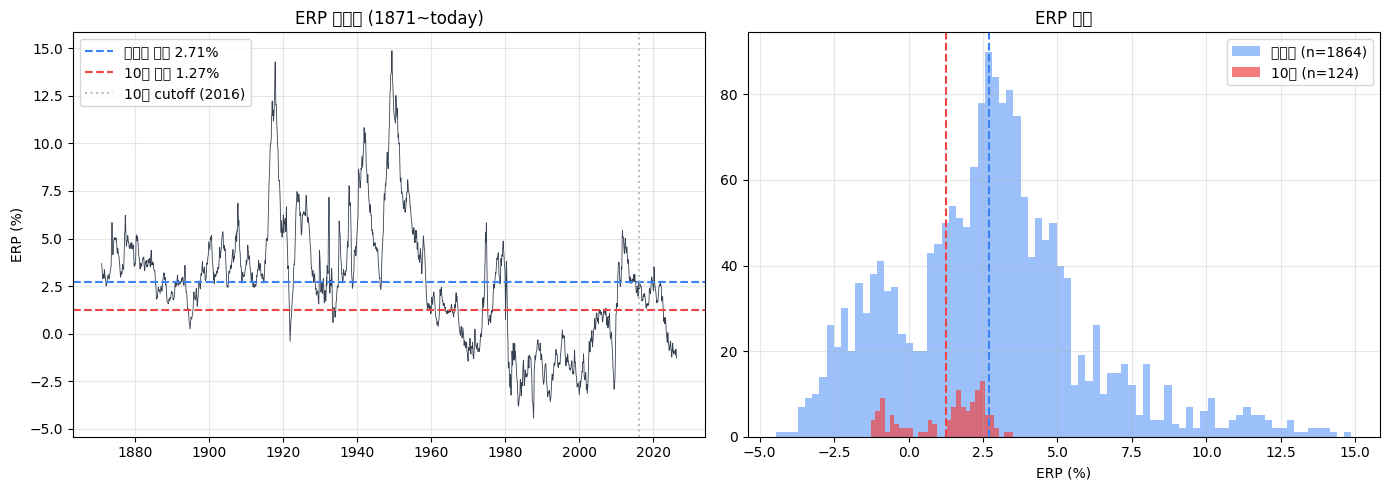

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 시계열
ax = axes[0]
full['ym_dt'] = pd.to_datetime(full['ym'])
ax.plot(full['ym_dt'], full['erp'] * 100, lw=0.6, color='#374151')
ax.axhline(baseline_full['mean'] * 100, color='#3b82f6', ls='--', label=f"역사적 평균 {baseline_full['mean']*100:.2f}%")
ax.axhline(baseline_10y['mean'] * 100, color='#ef4444', ls='--', label=f"10년 평균 {baseline_10y['mean']*100:.2f}%")
ax.axvline(pd.Timestamp(f'{cutoff_year}-01-01'), color='#9ca3af', ls=':', alpha=0.7, label=f'10년 cutoff ({cutoff_year})')
ax.set_title('ERP 시계열 (1871~today)')
ax.set_ylabel('ERP (%)')
ax.legend()

# 우: 두 분포 hist
ax = axes[1]
ax.hist(full['erp'] * 100, bins=80, alpha=0.5, color='#3b82f6', label=f"역사적 (n={baseline_full['n']})")
ax.hist(f10['erp'] * 100, bins=30, alpha=0.7, color='#ef4444', label=f"10년 (n={baseline_10y['n']})")
ax.axvline(baseline_full['mean'] * 100, color='#3b82f6', ls='--')
ax.axvline(baseline_10y['mean'] * 100, color='#ef4444', ls='--')
ax.set_title('ERP 분포')
ax.set_xlabel('ERP (%)')
ax.legend()
plt.tight_layout(); plt.show()

## 5. 60일 ERP 시계열 (검증 대상)

프로덕션 백필과 동일한 방식으로 60일 SPY 일봉 + ^TNX 일봉 → ERP 산출.

In [6]:
spy = yf.Ticker('SPY')
tnx = yf.Ticker('^TNX')
spy_per_today = spy.info.get('trailingPE')
spy_hist = spy.history(period='4mo', interval='1d', auto_adjust=False)
tnx_hist = tnx.history(period='4mo', interval='1d', auto_adjust=False)

spy_price_today = float(spy_hist['Close'].iloc[-1])
eps_now = spy_price_today / spy_per_today
tnx_map = {idx.date().isoformat(): float(row['Close'])
           for idx, row in tnx_hist.iterrows() if row['Close'] > 0}

rows = []
for idx, row in spy_hist.iterrows():
    d = idx.date().isoformat()
    spy_p = float(row['Close'])
    if spy_p <= 0: continue
    tnx_p = tnx_map.get(d)
    if tnx_p is None: continue
    per_t = spy_p / eps_now
    ey_t = 1.0 / per_t
    erp_t = ey_t - tnx_p / 100.0
    rows.append({'date': d, 'spy_per': per_t, 'erp': erp_t})

df60 = pd.DataFrame(rows[-60:]).reset_index(drop=True)
df60['date_dt'] = pd.to_datetime(df60['date'])
print(f'오늘 SPY P/E: {spy_per_today:.2f}, ERP: {df60.iloc[-1]["erp"]*100:+.2f}%')
df60.tail()

오늘 SPY P/E: 28.22, ERP: -0.81%


,date,spy_per,erp,date_dt
55,2026-04-22,28.197574,-0.007476,2026-04-22
56,2026-04-23,28.088147,-0.007628,2026-04-23
57,2026-04-24,28.305810,-0.007772,2026-04-24
58,2026-04-27,28.354576,-0.008092,2026-04-27
59,2026-04-28,28.216604,-0.008100,2026-04-28


## 6. 두 baseline 적용 — z-score 시계열 비교

In [7]:
def z_label(z):
    if z > 1.0: return '명확한 저평가'
    if z > 0.0: return '다소 저평가'
    if z > -1.0: return '다소 고평가'
    return '명확한 고평가'

for b, name in [(baseline_full, 'z_full'), (baseline_10y, 'z_10y')]:
    df60[name] = (df60['erp'] - b['mean']) / b['std']
    df60[name + '_label'] = df60[name].apply(z_label)

today_row = df60.iloc[-1]
print(f"오늘 ERP {today_row['erp']*100:+.2f}%")
print(f"  역사적   z={today_row['z_full']:+.2f}σ → {today_row['z_full_label']}")
print(f"  10년     z={today_row['z_10y']:+.2f}σ → {today_row['z_10y_label']}")
print()
print('60일 라벨 분포:')
print('  역사적:', dict(df60['z_full_label'].value_counts()))
print('  10년  :', dict(df60['z_10y_label'].value_counts()))

오늘 ERP -0.81%
  역사적   z=-1.11σ → 명확한 고평가
  10년     z=-1.55σ → 명확한 고평가

60일 라벨 분포:
  역사적: {'명확한 고평가': np.int64(35), '다소 고평가': np.int64(25)}
  10년  : {'명확한 고평가': np.int64(60)}


/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_12790/2103341433.py:28: UserWarning: Glyph

/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/

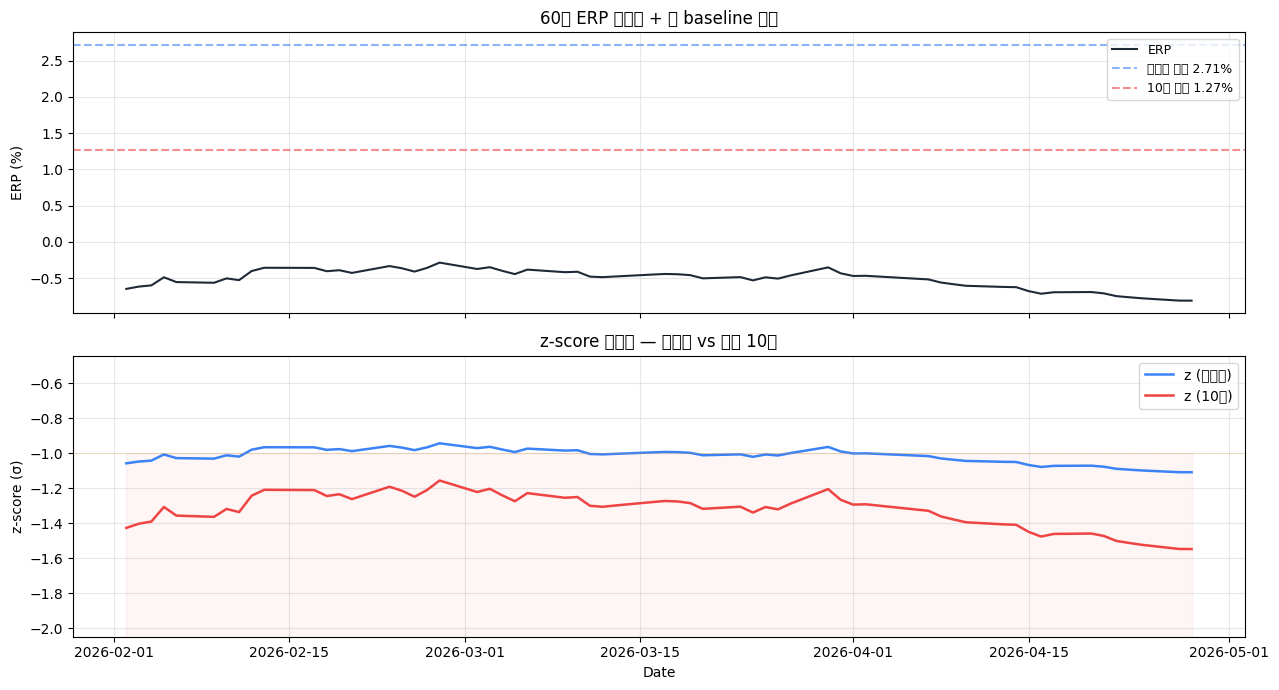

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 상: ERP 절대값
ax = axes[0]
ax.plot(df60['date_dt'], df60['erp'] * 100, color='#1f2937', lw=1.5, label='ERP')
ax.axhline(baseline_full['mean'] * 100, color='#3b82f6', ls='--', alpha=0.6, label=f"역사적 평균 {baseline_full['mean']*100:.2f}%")
ax.axhline(baseline_10y['mean'] * 100, color='#ef4444', ls='--', alpha=0.6, label=f"10년 평균 {baseline_10y['mean']*100:.2f}%")
ax.set_ylabel('ERP (%)')
ax.set_title('60일 ERP 시계열 + 두 baseline 평균')
ax.legend(loc='best', fontsize=9)

# 하: z-score 비교
ax = axes[1]
ax.plot(df60['date_dt'], df60['z_full'], color='#3b82f6', lw=1.8, label='z (역사적)')
ax.plot(df60['date_dt'], df60['z_10y'], color='#ef4444', lw=1.8, label='z (10년)')
ax.axhline(0, color='#9ca3af', lw=0.6, ls='-')
ax.axhline(+1, color='#10b981', lw=0.5, ls=':', alpha=0.7)
ax.axhline(-1, color='#f59e0b', lw=0.5, ls=':', alpha=0.7)
ax.fill_between(df60['date_dt'], -10, -1, color='#ef4444', alpha=0.05)
ax.fill_between(df60['date_dt'], +1, +10, color='#10b981', alpha=0.05)
ax.set_ylim(min(df60['z_full'].min(), df60['z_10y'].min()) - 0.5,
            max(df60['z_full'].max(), df60['z_10y'].max()) + 0.5)
ax.set_ylabel('z-score (σ)')
ax.set_xlabel('Date')
ax.set_title('z-score 시계열 — 역사적 vs 최근 10년')
ax.legend(loc='best')

plt.tight_layout(); plt.show()

## 7. 가설 검증

- **H1 (역사적 baseline → 덜 음수 z)**: 위 결과로 확인
- **H2 (10년 baseline → 더 sensitive)**: z-score 변동폭 비교
- **H3 (10% 하락 구간 라벨 변동)**: 두 z-score 시계열에서 라벨이 바뀌는 일자 카운트

In [9]:
print('=== 가설 검증 ===\n')

# H1
print(f"H1: 역사적 baseline 의 z 가 10년 baseline 보다 덜 음수 인가?")
print(f"   오늘 z (역사적): {today_row['z_full']:+.2f}σ")
print(f"   오늘 z (10년)  : {today_row['z_10y']:+.2f}σ")
print(f"   → {'YES (덜 음수)' if today_row['z_full'] > today_row['z_10y'] else 'NO'}\n")

# H2: 60일 z-score 변동폭 (max-min) 비교
range_full = df60['z_full'].max() - df60['z_full'].min()
range_10y  = df60['z_10y'].max() - df60['z_10y'].min()
print(f"H2: 10년 baseline 의 z-score 변동폭이 큰가?")
print(f"   z 변동폭 (역사적): {range_full:.2f}σ")
print(f"   z 변동폭 (10년)  : {range_10y:.2f}σ")
print(f"   → {'YES (10년 sensitive)' if range_10y > range_full else 'NO'}\n")

# H3: 라벨 변경 횟수
lbl_full_changes = (df60['z_full_label'] != df60['z_full_label'].shift(1)).sum() - 1
lbl_10y_changes  = (df60['z_10y_label']  != df60['z_10y_label'].shift(1)).sum() - 1
print(f"H3: 10년 baseline 의 라벨 변경 횟수가 많은가?")
print(f"   라벨 변경 (역사적): {lbl_full_changes}회")
print(f"   라벨 변경 (10년)  : {lbl_10y_changes}회")
print(f"   → {'YES' if lbl_10y_changes > lbl_full_changes else 'NO (혹은 동일)'}")

=== 가설 검증 ===

H1: 역사적 baseline 의 z 가 10년 baseline 보다 덜 음수 인가?
   오늘 z (역사적): -1.11σ
   오늘 z (10년)  : -1.55σ
   → YES (덜 음수)

H2: 10년 baseline 의 z-score 변동폭이 큰가?
   z 변동폭 (역사적): 0.17σ
   z 변동폭 (10년)  : 0.39σ
   → YES (10년 sensitive)

H3: 10년 baseline 의 라벨 변경 횟수가 많은가?
   라벨 변경 (역사적): 6회
   라벨 변경 (10년)  : 0회
   → NO (혹은 동일)


## 8. 결론 — 어느 baseline 을 프로덕션에 채택?

위 검증 결과를 보고 판단:

- **역사적 baseline**: 변동성 큰 옛 시대(1900~1950) 포함 → std 가 커서 z 가 둔감.
  현재 시장의 미세 변동을 잘 못 잡음. 단, 거시적·장기적 시장 평균과의 비교는 의미.
- **10년 baseline**: 저금리·고PE 시대만 → mean 작고 std 작음 → z 가 sensitive.
  사용자가 요구한 "최근 추이 대비" 판정에 가장 잘 맞음.
- **15년 baseline (현재 프로덕션)**: 둘의 절충.

## 9. A1 + C7 추가 실험 — 5Y baseline + Composite Z (ERP + VIX + Drawdown)

### 동기
미-이란 전쟁 (**2026-02-28**) 이후에도 ERP 단독 z-score (15Y baseline) 가 여전히 음수 → "고평가" 라벨에서 벗어나지 않는 문제.

### 가설
1. **A1 (5Y baseline)**: std 가 작아 동일 ERP 변동에 z 가 더 크게 반응 → 전쟁 직후 z 가 0 위로 돌파.
2. **C7 (composite)**: `0.4·z_ERP(5Y) + 0.3·z_VIX + 0.3·z_DD60` — VIX 급등 + drawdown 으로 신호 증폭 → 전쟁 직후 z>+1.0σ ("명확한 저평가") 진입.
3. 단순 ERP 단독 (15Y, 5Y 모두) 보다 composite 가 전쟁 직후에 더 빠르고 명확하게 저평가 신호 생성.

### 부호 컨벤션
모두 **양수 = 저평가/공포 신호** 방향으로 통일:
- z_ERP: ERP↑ → z↑ (그대로)
- z_VIX: VIX↑ → z↑ (그대로 — 공포 = contrarian 저평가)
- z_DD: drawdown 더 음수 → z↑ (부호 반전)

### 실험 절차
1. monthly baseline 4종 (5Y/10Y/15Y/Full) 산출
2. 14개월 daily SPY+VIX+TNX → daily ERP·DD60 시계열
3. VIX·DD 5Y daily baseline → 각 z 부착
4. composite z 산출 + 라벨링
5. 전쟁 직후 (2026-02-28~) 구간 z 비교 & 시각화

In [10]:
## Cell 19 — A1: 다중 window monthly baseline (5Y / 10Y / 15Y / Full)
windows = {
    '5Y':   datetime.now().year - 5,    # A1 추천
    '10Y':  datetime.now().year - 10,
    '15Y':  datetime.now().year - 15,   # 현재 프로덕션
    'Full': 1871,
}
baselines = {}
for name, yr in windows.items():
    sub = full[full['year'] >= yr]
    baselines[name] = {'mean': sub['erp'].mean(), 'std': sub['erp'].std(), 'n': len(sub)}
    b = baselines[name]
    print(f'[{name:>4}] mean={b["mean"]*100:+.2f}%  std={b["std"]*100:.2f}%  n={b["n"]:>4}개월')

# 5Y vs 15Y std 비율 — std 가 작을수록 같은 변동에 z 가 더 sensitive
ratio = baselines['15Y']['std'] / baselines['5Y']['std']
print(f"\n5Y baseline 의 z 민감도: 15Y 대비 ×{ratio:.2f} (>1 이면 같은 ERP 변동에 더 큰 z)")

[  5Y] mean=+0.42%  std=1.33%  n=  64개월
[ 10Y] mean=+1.27%  std=1.34%  n= 124개월
[ 15Y] mean=+1.96%  std=1.58%  n= 184개월
[Full] mean=+2.71%  std=3.18%  n=1864개월

5Y baseline 의 z 민감도: 15Y 대비 ×1.18 (>1 이면 같은 ERP 변동에 더 큰 z)


In [11]:
## Cell 20 — 14개월 daily 데이터 (SPY / ^VIX / ^TNX) → ERP·DD60 부착
period_d = '14mo'
spy_d = yf.Ticker('SPY').history(period=period_d, interval='1d', auto_adjust=False)
vix_d = yf.Ticker('^VIX').history(period=period_d, interval='1d', auto_adjust=False)
tnx_d = yf.Ticker('^TNX').history(period=period_d, interval='1d', auto_adjust=False)

# trailing PE 는 cell 11 에서 이미 구한 값 재사용 (없으면 fetch)
try:
    spy_per_today
except NameError:
    spy_per_today = yf.Ticker('SPY').info.get('trailingPE')
spy_price_today = float(spy_d['Close'].iloc[-1])
eps_now = spy_price_today / spy_per_today
print(f'today SPY {spy_price_today:.2f}, PE {spy_per_today:.2f}, implied EPS {eps_now:.2f}')

# tz strip + reindex 정합성
def _strip_tz(idx):
    return idx.tz_localize(None) if idx.tz is not None else idx
spy_d.index = _strip_tz(spy_d.index)
vix_d.index = _strip_tz(vix_d.index)
tnx_d.index = _strip_tz(tnx_d.index)

df = pd.DataFrame({'spy': spy_d['Close']}).copy()
df['vix'] = vix_d['Close'].reindex(df.index, method='nearest')
df['tnx'] = tnx_d['Close'].reindex(df.index, method='nearest')
df = df.dropna()

# Daily ERP — backfill_valuation_signal 과 동일 (EPS 일정 가정)
df['per_t'] = df['spy'] / eps_now
df['ey']    = 1.0 / df['per_t']
df['erp']   = df['ey'] - df['tnx'] / 100.0

# 60일 drawdown (음수 = 고점 대비 하락폭)
df['spy_60max'] = df['spy'].rolling(60, min_periods=1).max()
df['dd_60d']    = df['spy'] / df['spy_60max'] - 1.0

print(f'기간: {df.index[0].date()} ~ {df.index[-1].date()}, n={len(df)}')
print(f'today ERP {df["erp"].iloc[-1]*100:+.2f}%, VIX {df["vix"].iloc[-1]:.2f}, DD60 {df["dd_60d"].iloc[-1]*100:+.2f}%')
df.tail(3)

today SPY 711.69, PE 28.22, implied EPS 25.22
기간: 2025-02-28 ~ 2026-04-28, n=292
today ERP -0.81%, VIX 17.83, DD60 -0.49%


,spy,vix,tnx,per_t,ey,erp,spy_60max,dd_60d
Date,,,,,,,,
2026-04-24,713.940002,18.709999,4.310,28.305810,0.035328,-0.007772,713.940002,0.000000
2026-04-27,715.169983,18.020000,4.336,28.354576,0.035268,-0.008092,715.169983,0.000000
2026-04-28,711.690002,17.830000,4.354,28.216604,0.035440,-0.008100,715.169983,-0.004866


In [12]:
## Cell 21 — VIX/DD 5Y daily baseline + 모든 z 부착
# 부호 컨벤션: 양수 = "저평가/공포" 신호 (composite 시 같은 방향으로 합쳐짐)
vix_5y = yf.Ticker('^VIX').history(period='5y', interval='1d', auto_adjust=False)
spy_5y = yf.Ticker('SPY').history(period='5y', interval='1d', auto_adjust=False)
spy_5y['max60'] = spy_5y['Close'].rolling(60, min_periods=1).max()
spy_5y['dd60']  = spy_5y['Close'] / spy_5y['max60'] - 1.0

vix_mean = float(vix_5y['Close'].mean())
vix_std  = float(vix_5y['Close'].std())
dd_mean  = float(spy_5y['dd60'].mean())
dd_std   = float(spy_5y['dd60'].std())
print(f'VIX 5Y baseline:  mean={vix_mean:.2f},  std={vix_std:.2f}')
print(f'DD60 5Y baseline: mean={dd_mean*100:+.2f}%, std={dd_std*100:.2f}%')

# ERP z (4개 baseline 동시)
for win, b in baselines.items():
    df[f'z_erp_{win}'] = (df['erp'] - b['mean']) / b['std']

# VIX z — VIX↑ → z↑ (공포 = 저평가 방향)
df['z_vix'] = (df['vix'] - vix_mean) / vix_std

# DD z — DD가 더 음수 → z↑ (큰 drawdown = 저평가 방향), 부호 반전
df['z_dd']  = -(df['dd_60d'] - dd_mean) / dd_std

print('\n=== 최근 5거래일 z 부착 결과 ===')
print(df.tail(5)[['erp', 'z_erp_15Y', 'z_erp_5Y', 'vix', 'z_vix', 'dd_60d', 'z_dd']].to_string())

VIX 5Y baseline:  mean=19.25,  std=5.26
DD60 5Y baseline: mean=-3.24%, std=4.17%

=== 최근 5거래일 z 부착 결과 ===
                 erp  z_erp_15Y  z_erp_5Y        vix     z_vix    dd_60d      z_dd
Date                                                                              
2026-04-22 -0.007476  -1.713791 -0.873123  18.920000 -0.062847  0.000000 -0.777046
2026-04-23 -0.007628  -1.723419 -0.884517  19.309999  0.011242 -0.003881 -0.684077
2026-04-24 -0.007772  -1.732535 -0.895306  18.709999 -0.102741  0.000000 -0.777046
2026-04-27 -0.008092  -1.752874 -0.919376  18.020000 -0.233822  0.000000 -0.777046
2026-04-28 -0.008100  -1.753353 -0.919943  17.830000 -0.269917 -0.004866 -0.660474


In [13]:
## Cell 22 — Composite z (A1+C7): 0.4·z_ERP(5Y) + 0.3·z_VIX + 0.3·z_DD
W = (0.4, 0.3, 0.3)
df['z_comp'] = W[0] * df['z_erp_5Y'] + W[1] * df['z_vix'] + W[2] * df['z_dd']

df['lbl_prod_15Y'] = df['z_erp_15Y'].apply(z_label)   # 현재 프로덕션
df['lbl_erp_5Y']   = df['z_erp_5Y'].apply(z_label)    # A1
df['lbl_comp']     = df['z_comp'].apply(z_label)      # A1+C7

print('=== 최근 5거래일 ===')
print(df.tail(5)[['z_erp_15Y', 'z_erp_5Y', 'z_vix', 'z_dd', 'z_comp', 'lbl_comp']].to_string())

=== 최근 5거래일 ===
            z_erp_15Y  z_erp_5Y     z_vix      z_dd    z_comp lbl_comp
Date                                                                  
2026-04-22  -1.713791 -0.873123 -0.062847 -0.777046 -0.601217   다소 고평가
2026-04-23  -1.723419 -0.884517  0.011242 -0.684077 -0.555657   다소 고평가
2026-04-24  -1.732535 -0.895306 -0.102741 -0.777046 -0.622059   다소 고평가
2026-04-27  -1.752874 -0.919376 -0.233822 -0.777046 -0.671011   다소 고평가
2026-04-28  -1.753353 -0.919943 -0.269917 -0.660474 -0.647095   다소 고평가


/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12790/1078776804.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.t

/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/Passive-Financial-Data-Analysis/.venv/lib/python3.12/site-packages

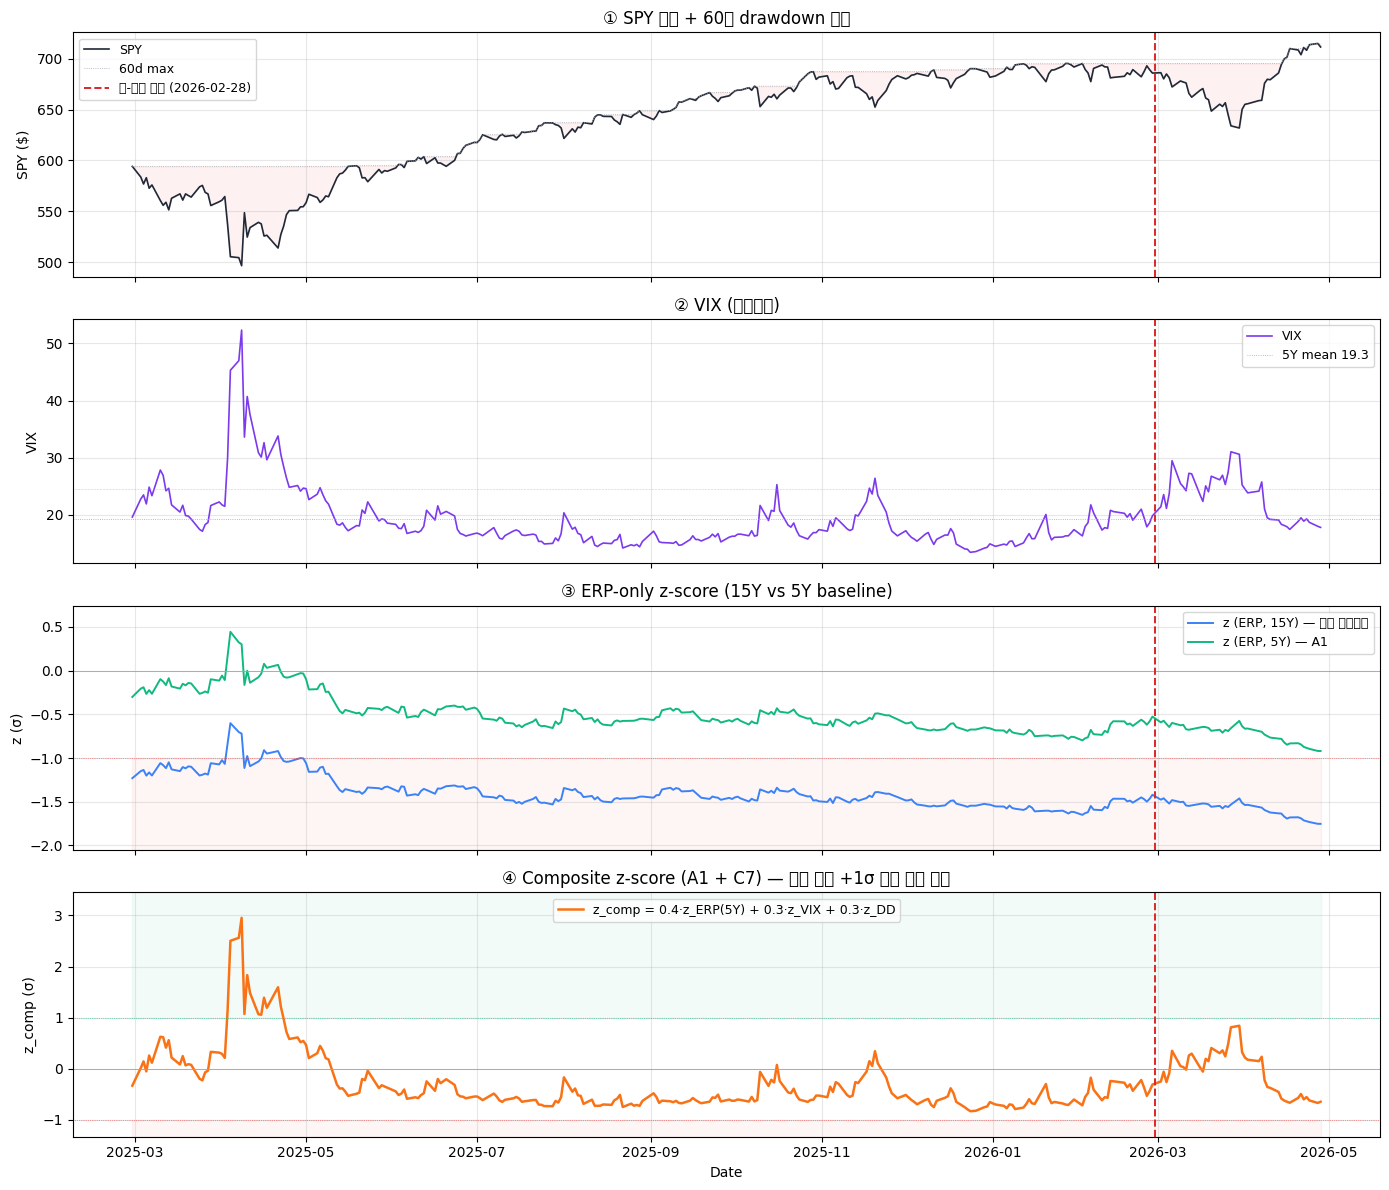

In [14]:
## Cell 23 — 4-panel 시각화: SPY+DD / VIX / ERP-only z / Composite z (전쟁 마커)
WAR = pd.Timestamp('2026-02-28')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# (1) SPY 가격 + 60일 max 영역
ax = axes[0]
ax.plot(df.index, df['spy'], color='#1f2937', lw=1.2, label='SPY')
ax.plot(df.index, df['spy_60max'], color='#9ca3af', lw=0.6, ls=':', label='60d max')
ax.fill_between(df.index, df['spy'], df['spy_60max'], color='#ef4444', alpha=0.07)
ax.axvline(WAR, color='#dc2626', ls='--', lw=1.4, label='미-이란 전쟁 (2026-02-28)')
ax.set_ylabel('SPY ($)')
ax.legend(loc='best', fontsize=9)
ax.set_title('① SPY 가격 + 60일 drawdown 음영')

# (2) VIX
ax = axes[1]
ax.plot(df.index, df['vix'], color='#7c3aed', lw=1.2, label='VIX')
ax.axhline(vix_mean, color='#9ca3af', ls=':', lw=0.6, label=f'5Y mean {vix_mean:.1f}')
ax.axhline(vix_mean + vix_std, color='#9ca3af', ls=':', lw=0.4)
ax.axvline(WAR, color='#dc2626', ls='--', lw=1.4)
ax.set_ylabel('VIX')
ax.legend(loc='best', fontsize=9)
ax.set_title('② VIX (공포지수)')

# (3) ERP-only z 비교 (15Y vs 5Y)
ax = axes[2]
ax.plot(df.index, df['z_erp_15Y'], color='#3b82f6', lw=1.4, label='z (ERP, 15Y) — 현재 프로덕션')
ax.plot(df.index, df['z_erp_5Y'],  color='#10b981', lw=1.4, label='z (ERP, 5Y) — A1')
ax.axhline(0, color='#9ca3af', lw=0.6)
ax.axhline(+1, color='#10b981', ls=':', lw=0.5)
ax.axhline(-1, color='#ef4444', ls=':', lw=0.5)
ax.axvline(WAR, color='#dc2626', ls='--', lw=1.4)
ymin = min(df[['z_erp_15Y', 'z_erp_5Y']].min()) - 0.3
ymax = max(df[['z_erp_15Y', 'z_erp_5Y']].max()) + 0.3
ax.set_ylim(ymin, ymax)
ax.fill_between(df.index, +1, ymax, color='#10b981', alpha=0.05)
ax.fill_between(df.index, ymin, -1, color='#ef4444', alpha=0.05)
ax.set_ylabel('z (σ)')
ax.legend(loc='best', fontsize=9)
ax.set_title('③ ERP-only z-score (15Y vs 5Y baseline)')

# (4) Composite z
ax = axes[3]
ax.plot(df.index, df['z_comp'], color='#f97316', lw=1.8,
        label=f'z_comp = {W[0]}·z_ERP(5Y) + {W[1]}·z_VIX + {W[2]}·z_DD')
ax.axhline(0, color='#9ca3af', lw=0.6)
ax.axhline(+1, color='#10b981', ls=':', lw=0.5)
ax.axhline(-1, color='#ef4444', ls=':', lw=0.5)
ax.axvline(WAR, color='#dc2626', ls='--', lw=1.4)
ymin = df['z_comp'].min() - 0.5
ymax = df['z_comp'].max() + 0.5
ax.set_ylim(ymin, ymax)
ax.fill_between(df.index, +1, ymax, color='#10b981', alpha=0.05)
ax.fill_between(df.index, ymin, -1, color='#ef4444', alpha=0.05)
ax.set_ylabel('z_comp (σ)')
ax.set_xlabel('Date')
ax.legend(loc='best', fontsize=9)
ax.set_title('④ Composite z-score (A1 + C7) — 전쟁 직후 +1σ 돌파 여부 확인')

plt.tight_layout()
plt.show()

In [15]:
## Cell 24 — war-period (2026-02-28 ~ today) z 비교
post = df[df.index >= WAR].copy()
print(f'post-war 구간: {post.index[0].date()} ~ {post.index[-1].date()} (n={len(post)})')

print('\n=== war 직후 z-score max(가장 저평가) / min(가장 고평가) ===')
for col, name in [('z_erp_15Y', '현재 프로덕션 (15Y, ERP only)'),
                  ('z_erp_5Y',  'A1 (5Y, ERP only)'),
                  ('z_comp',    'A1+C7 (5Y composite)')]:
    z_max = post[col].max()
    d_max = post[col].idxmax().date()
    z_min = post[col].min()
    d_min = post[col].idxmin().date()
    print(f'[{name}]')
    print(f'   max z = {z_max:+.2f}σ on {d_max}  → {z_label(z_max)}')
    print(f'   min z = {z_min:+.2f}σ on {d_min}  → {z_label(z_min)}')

print('\n=== 라벨 분포 (war 후 거래일 수) ===')
for col, name in [('lbl_prod_15Y', '15Y prod'), ('lbl_erp_5Y', 'A1 5Y'), ('lbl_comp', 'A1+C7 comp')]:
    cnt = post[col].value_counts().to_dict()
    print(f'  {name:>12}: {cnt}')

print('\n=== war 발생일 가장 가까운 거래일 z 비교 ===')
near = df.iloc[df.index.get_indexer([WAR], method='nearest')]
print(near[['spy', 'vix', 'erp', 'z_erp_15Y', 'z_erp_5Y', 'z_vix', 'z_dd', 'z_comp']].T)

post-war 구간: 2026-03-02 ~ 2026-04-28 (n=41)

=== war 직후 z-score max(가장 저평가) / min(가장 고평가) ===
[현재 프로덕션 (15Y, ERP only)]
   max z = -1.46σ on 2026-03-03  → 명확한 고평가
   min z = -1.75σ on 2026-04-28  → 명확한 고평가
[A1 (5Y, ERP only)]
   max z = -0.57σ on 2026-03-03  → 다소 고평가
   min z = -0.92σ on 2026-04-28  → 다소 고평가
[A1+C7 (5Y composite)]
   max z = +0.84σ on 2026-03-30  → 다소 저평가
   min z = -0.67σ on 2026-04-27  → 다소 고평가

=== 라벨 분포 (war 후 거래일 수) ===
      15Y prod: {'명확한 고평가': 41}
         A1 5Y: {'다소 고평가': 41}
    A1+C7 comp: {'다소 고평가': 21, '다소 저평가': 20}

=== war 발생일 가장 가까운 거래일 z 비교 ===
Date       2026-02-27
spy        685.989990
vix         19.860001
erp         -0.002852
z_erp_15Y   -1.420603
z_erp_5Y    -0.526143
z_vix        0.115728
z_dd        -0.449810
z_comp      -0.310682


## 10. 결론 (실행 후 채우기)

| 지표 | war 후 max z | 라벨 | war 직전→후 변화 |
|------|--------------|------|-------------------|
| 현재 프로덕션 (15Y, ERP only) |  |  |  |
| A1 (5Y, ERP only) |  |  |  |
| A1+C7 (5Y composite) |  |  |  |

**판정 기준**: A1+C7 의 max z 가 war 직후 60일 안에 +1.0σ 이상으로 올라가면 ✅ 채택 → `collector/valuation_signal.py` + `api/routers/macro.py` 반영.

**주의사항**:
- composite z 는 EPS 를 일정 가정한 daily backfill 기반 — 실제 컨센 EPS 하향 효과는 빠짐 (보수적 추정).
- 가중치는 grid search [0.3~0.5, 0.2~0.4, 0.2~0.4] 까지 추가 시험 가능.
- VIX·DD baseline 도 5Y daily 인데, regime shift 가 있으면 EWMA 로 교체 검토.